# Step 5: Hybrid Scoring

## Overview
Combine semantic similarity with recency for ranking candidate papers.

$$\text{final\_score} = \alpha \times \text{cosine\_sim}(\text{user\_vector}, \text{paper\_vec}) + (1-\alpha) \times \text{recency\_score}$$

Where:
- $\alpha = 0.7$ (fixed weight for semantic similarity)
- $\text{recency\_score} = 1 - \frac{\text{days\_since\_published}}{\text{max\_days}}$

## BƯỚC 1: Import & Load Data

In [13]:
%pip install pandas numpy scipy scikit-learn joblib -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import json
import scipy.sparse
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime, timedelta
from preprocess import TextPreprocessor
import warnings
warnings.filterwarnings('ignore')

# Hybrid scoring parameters
ALPHA = 0.7  # Weight for semantic similarity
HALF_LIFE = 90  # Days (select one: 30, 60, or 90)

print(f"Hybrid Scoring Configuration:")
print(f"  alpha (semantic weight) = {ALPHA}")
print(f"  recency weight = {1 - ALPHA}")
print(f"  using half_life = {HALF_LIFE} days")

Hybrid Scoring Configuration:
  alpha (semantic weight) = 0.7
  recency weight = 0.30000000000000004
  using half_life = 90 days


In [26]:
# Load user vectors and metadata
vectors_file = f'user_profiles/user_vectors_halflife_{HALF_LIFE}.npz'
metadata_file = f'user_profiles/user_metadata_halflife_{HALF_LIFE}.json'

data = np.load(vectors_file)
user_vectors = data['vectors']  # Shape: (1000, 10000)

with open(metadata_file, 'r') as f:
    user_metadata = json.load(f)

print(f"✓ Loaded user vectors: {user_vectors.shape}")
print(f"✓ Loaded user metadata: {len(user_metadata)} users")

✓ Loaded user vectors: (1000, 10000)
✓ Loaded user metadata: 1000 users


In [27]:
# Load TF-IDF matrix and synthetic users
tfidf_matrix = scipy.sparse.load_npz('tfidf_matrix.npz')

with open('UserDataGenerator/synthetic_users.json', 'r') as f:
    data_json = json.load(f)
    users = data_json['train']

print(f"✓ Loaded TF-IDF matrix: {tfidf_matrix.shape}")
print(f"✓ Loaded {len(users)} synthetic users")

✓ Loaded TF-IDF matrix: (136238, 10000)
✓ Loaded 1000 synthetic users


## BƯỚC 2: Calculate Recency Scores

In [28]:
# Extract all unique papers and create recency scores
import pandas as pd
df_train = pd.read_csv('train.csv')
paper_ids_in_system = set()
for user in users:
    for paper_id, days_ago in user['train_history']:
        paper_ids_in_system.add(paper_id)
    paper_ids_in_system.add(user['target_paper'])
    paper_ids_in_system.update(user['negative_papers'])

paper_ids_in_system = sorted(list(paper_ids_in_system))
print(f"Total unique papers in system: {len(paper_ids_in_system)}")

# Create recency scores based on paper_id (extract date info)
paper_id_to_recency = {}
#reference_date = datetime(2026, 6, 16)
#max_days_in_dataset = 1000  # Assume papers span ~3 years

'''for idx, paper_id in enumerate(paper_ids_in_system):
    # Try to extract date from paper_id format: abs-YYMMNNNNN
    try:
        parts = paper_id.split('-')
        if len(parts) >= 2 and len(parts[1]) >= 4:
            year_month = parts[1][:6]  # e.g., "200501"
            if year_month.isdigit():
                year = int('20' + year_month[:2])
                month = int(year_month[2:4])
                day = 15  # Use day 15 as default
                if 1 <= month <= 12:
                    pub_date = datetime(year, month, day)
                    days_since = (reference_date - pub_date).days
                    recency = 1.0 - min(1.0, days_since / max_days_in_dataset)
                    paper_id_to_recency[paper_id] = max(0.0, recency)
                else:
                    raise ValueError
            else:
                raise ValueError
        else:
            raise ValueError
    except:
        # Fallback: assign based on paper position
        recency = 0.3 + (idx % 1000) / 2000.0
        paper_id_to_recency[paper_id] = recency'''
paper_id_to_recency = dict(zip(df_train['paper_id'],df_train['recency_score']))

print(f"✓ Created recency scores for {len(paper_id_to_recency)} papers")
print(f"\nRecency statistics:")
recencies = list(paper_id_to_recency.values())
print(f"  min:    {min(recencies):.4f}")
print(f"  max:    {max(recencies):.4f}")
print(f"  mean:   {np.mean(recencies):.4f}")

Total unique papers in system: 26188
✓ Created recency scores for 136238 papers

Recency statistics:
  min:    0.0500
  max:    0.0700
  mean:   0.0508


## BƯỚC 3: Create Paper ID to Index Mapping

In [30]:
# Create mapping from paper_id to tfidf_matrix index
paper_id_to_idx = {pid: idx for idx, pid in enumerate(sorted(paper_ids_in_system))}
idx_to_paper_id = {idx: pid for pid, idx in paper_id_to_idx.items()}

print(f"✓ Created paper_id ↔ index mapping: {len(paper_id_to_idx)} papers")
print(f"\nMapping sample:")
for i, (pid, idx) in enumerate(list(paper_id_to_idx.items())[:5]):
    print(f"  {pid} -> {idx}")

✓ Created paper_id ↔ index mapping: 26188 papers

Mapping sample:
  abs-0704.1394v1 -> 0
  abs-0704.2083v1 -> 1
  abs-0705.0214v1 -> 2
  abs-0705.0828v1 -> 3
  abs-0705.0952v1 -> 4


## BƯỚC 4: Implement Hybrid Scoring Function

In [36]:
def compute_hybrid_scores_vectorized(user_vector, candidate_paper_ids, paper_id_to_idx, 
                                     paper_id_to_recency, tfidf_matrix, alpha=0.7):
    """
    Vectorized hybrid scoring for candidate papers.
    
    final_score = alpha * cosine_sim + (1 - alpha) * recency_score
    
    Args:
        user_vector: 1D array of shape (10000,)
        candidate_paper_ids: List of paper IDs to rank
        paper_id_to_idx: Dict mapping paper_id -> matrix index
        paper_id_to_recency: Dict mapping paper_id -> recency_score
        tfidf_matrix: Sparse TF-IDF matrix
        alpha: Weight for semantic similarity (default 0.7)
    
    Returns:
        scored_papers: List of dicts with scores
    """
    # Filter valid papers and get indices
    valid_papers = []
    valid_indices = []
    
    for paper_id in candidate_paper_ids:
        if paper_id in paper_id_to_idx:
            valid_papers.append(paper_id)
            valid_indices.append(paper_id_to_idx[paper_id])
    
    if not valid_papers:
        return []
    
    # Extract candidate vectors as sparse matrix
    candidate_vectors = tfidf_matrix[valid_indices]  # Sparse matrix shape (n_papers, 10000)
    
    # Compute all cosine similarities at once
    # user_vector shape: (10000,) -> reshape to (1, 10000) for matrix multiplication
    user_vector_reshaped = np.array(user_vector).reshape(1, -1)
    
    # For sparse matrix: use sparse @ dense multiplication
    if hasattr(candidate_vectors, 'toarray'):  # It's sparse
        sim_scores = cosine_similarity(user_vector_reshaped, candidate_vectors)[0]
    else:  # Dense
        sim_scores = cosine_similarity(user_vector_reshaped, candidate_vectors)[0]
    
    # Build results
    scored_papers = []
    for i, paper_id in enumerate(valid_papers):
        sim_score = float(sim_scores[i])
        recency_score = paper_id_to_recency.get(paper_id, 0.5)
        final_score = alpha * sim_score + (1 - alpha) * recency_score
        
        scored_papers.append({
            'paper_id': paper_id,
            'sim_score': sim_score,
            'recency_score': recency_score,
            'final_score': final_score
        })
    
    # Sort by final_score descending
    scored_papers.sort(key=lambda x: x['final_score'], reverse=True)
    
    return scored_papers

print("✓ Defined compute_hybrid_scores_vectorized function")

✓ Defined compute_hybrid_scores_vectorized function


## BƯỚC 5: Test Hybrid Scoring on Sample User

In [37]:
# Test on first user
user_idx = 0
user_id = user_metadata[user_idx]['user_id']
user_vector = user_vectors[user_idx]  # Already dense

# Get all paper IDs and remove papers already in training history
all_paper_ids = set(paper_id_to_recency.keys())
read_papers = set([paper_id for paper_id, _ in users[user_idx]['train_history']])
candidate_ids = list(all_paper_ids - read_papers)

# Compute scores using vectorized function
scored = compute_hybrid_scores_vectorized(
    user_vector,
    candidate_ids,
    paper_id_to_idx,
    paper_id_to_recency,
    tfidf_matrix,
    alpha=ALPHA
)

# Show top 10
print(f"Testing on {user_id}")
print(f"User vector shape: {user_vector.shape}")
print(f"User vector norm: {np.linalg.norm(user_vector):.4f}")
print(f"\nCandidate papers to score: {len(candidate_ids)}")
print(f"\n✓ Computed hybrid scores for {len(scored)} papers")
print(f"\nTop 10 recommendations for {user_id}:")
print("-" * 110)
print(f"{'Rank':<6} {'Paper ID':<20} {'Similarity':<12} {'Recency':<12} {'Final Score':<12}")
print("-" * 110)

for rank, rec in enumerate(scored[:10], 1):
    print(f"{rank:<6} {rec['paper_id']:<20} {rec['sim_score']:<12.4f} {rec['recency_score']:<12.4f} {rec['final_score']:<12.4f}")

Testing on user_0001
User vector shape: (10000,)
User vector norm: 0.2142

Candidate papers to score: 136196

✓ Computed hybrid scores for 26146 papers

Top 10 recommendations for user_0001:
--------------------------------------------------------------------------------------------------------------
Rank   Paper ID             Similarity   Recency      Final Score 
--------------------------------------------------------------------------------------------------------------
1      abs-1905.00982v1     0.2644       0.0500       0.2001      
2      abs-1902.01722v1     0.2601       0.0500       0.1971      
3      abs-1911.05521v1     0.2533       0.0500       0.1923      
4      abs-2304.14543v1     0.2398       0.0501       0.1829      
5      abs-1811.08345v4     0.2390       0.0500       0.1823      
6      abs-1904.02242v1     0.2334       0.0500       0.1783      
7      abs-1605.08150v1     0.2314       0.0500       0.1769      
8      abs-1706.02430v1     0.2298       0.0500    

## BƯỚC 6: Generate Hybrid Scores for All Users

In [38]:
# Generate recommendations for all users
print(f"Generating hybrid scores for all {len(users)} users...\n")

all_recommendations = []

for user_idx, user_data in enumerate(users):
    user_id = user_metadata[user_idx]['user_id']
    user_vector = user_vectors[user_idx]  # Already dense
    
    # Get candidate papers: exclude papers already in training history
    read_papers = set(pid for pid, _ in user_data['train_history'])
    all_paper_ids = set(paper_ids_in_system)
    candidate_ids = list(all_paper_ids - read_papers)
    
    # Compute scores (vectorized for efficiency)
    scored = compute_hybrid_scores_vectorized(
        user_vector,
        candidate_ids,
        paper_id_to_idx,
        paper_id_to_recency,
        tfidf_matrix,
        alpha=ALPHA
    )
    
    # Store top-K recommendations
    top_k = 10
    recommendations = {
        'user_id': user_id,
        'archetype': user_data['archetype'],
        'user_type': user_data['user_type'],
        'target_paper': user_data['target_paper'],
        'recommendations': [
            {
                'rank': rank,
                'paper_id': paper_data['paper_id'],
                'sim_score': float(paper_data['sim_score']),
                'recency_score': float(paper_data['recency_score']),
                'final_score': float(paper_data['final_score'])
            }
            for rank, paper_data in enumerate(scored[:top_k], 1)
        ]
    }
    
    all_recommendations.append(recommendations)
    
    if (user_idx + 1) % 200 == 0:
        print(f"  Processed {user_idx + 1}/{len(users)} users")

print(f"\n✓ Generated recommendations for all {len(all_recommendations)} users")

Generating hybrid scores for all 1000 users...

  Processed 200/1000 users
  Processed 400/1000 users
  Processed 600/1000 users
  Processed 800/1000 users
  Processed 1000/1000 users

✓ Generated recommendations for all 1000 users


## BƯỚC 7: Save Recommendations

In [39]:
import os

os.makedirs('recommendations', exist_ok=True)

# Save all recommendations
output_file = f'recommendations/hybrid_scores_alpha_{ALPHA}_halflife_{HALF_LIFE}.json'
with open(output_file, 'w') as f:
    json.dump(all_recommendations, f, indent=2)

print(f"✓ Saved recommendations: {output_file}")

# Save summary config
summary = {
    'alpha': ALPHA,
    'half_life': HALF_LIFE,
    'total_users': len(all_recommendations),
    'top_k_kept': 10,
    'formula': 'final_score = alpha * cosine_sim + (1-alpha) * recency_score'
}

summary_file = f'recommendations/config_alpha_{ALPHA}_halflife_{HALF_LIFE}.json'
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Saved config: {summary_file}")

✓ Saved recommendations: recommendations/hybrid_scores_alpha_0.7_halflife_90.json
✓ Saved config: recommendations/config_alpha_0.7_halflife_90.json


## BƯỚC 8: Analysis & Visualization

In [23]:
import matplotlib.pyplot as plt

# Collect all scores for analysis
all_final_scores = []
all_sim_scores = []
all_recency_scores = []

for user_rec in all_recommendations:
    for rec in user_rec['recommendations']:
        all_final_scores.append(rec['final_score'])
        all_sim_scores.append(rec['sim_score'])
        all_recency_scores.append(rec['recency_score'])

print("\n" + "="*70)
print(f"HYBRID SCORING ANALYSIS (alpha={ALPHA}, half_life={HALF_LIFE})")
print("="*70)

print(f"\nSemantic Similarity Scores:")
print(f"  min:    {min(all_sim_scores):.6f}")
print(f"  max:    {max(all_sim_scores):.6f}")
print(f"  mean:   {np.mean(all_sim_scores):.6f}")
print(f"  median: {np.median(all_sim_scores):.6f}")

print(f"\nRecency Scores:")
print(f"  min:    {min(all_recency_scores):.6f}")
print(f"  max:    {max(all_recency_scores):.6f}")
print(f"  mean:   {np.mean(all_recency_scores):.6f}")
print(f"  median: {np.median(all_recency_scores):.6f}")

print(f"\nFinal Hybrid Scores:")
print(f"  min:    {min(all_final_scores):.6f}")
print(f"  max:    {max(all_final_scores):.6f}")
print(f"  mean:   {np.mean(all_final_scores):.6f}")
print(f"  median: {np.median(all_final_scores):.6f}")

# Contribution analysis
alpha_contribution = ALPHA * np.mean(all_sim_scores)
recency_contribution = (1 - ALPHA) * np.mean(all_recency_scores)

print(f"\nScore Contribution (average):")
print(f"  Semantic (α={ALPHA}):       {alpha_contribution:.6f}")
print(f"  Recency  (1-α={1-ALPHA}):       {recency_contribution:.6f}")


HYBRID SCORING ANALYSIS (alpha=0.7, half_life=60)

Semantic Similarity Scores:
  min:    0.171033
  max:    0.813661
  mean:   0.250007
  median: 0.243948

Recency Scores:
  min:    0.050000
  max:    0.070044
  mean:   0.050536
  median: 0.050000

Final Hybrid Scores:
  min:    0.134723
  max:    0.584563
  mean:   0.190166
  median: 0.185922

Score Contribution (average):
  Semantic (α=0.7):       0.175005
  Recency  (1-α=0.30000000000000004):       0.015161


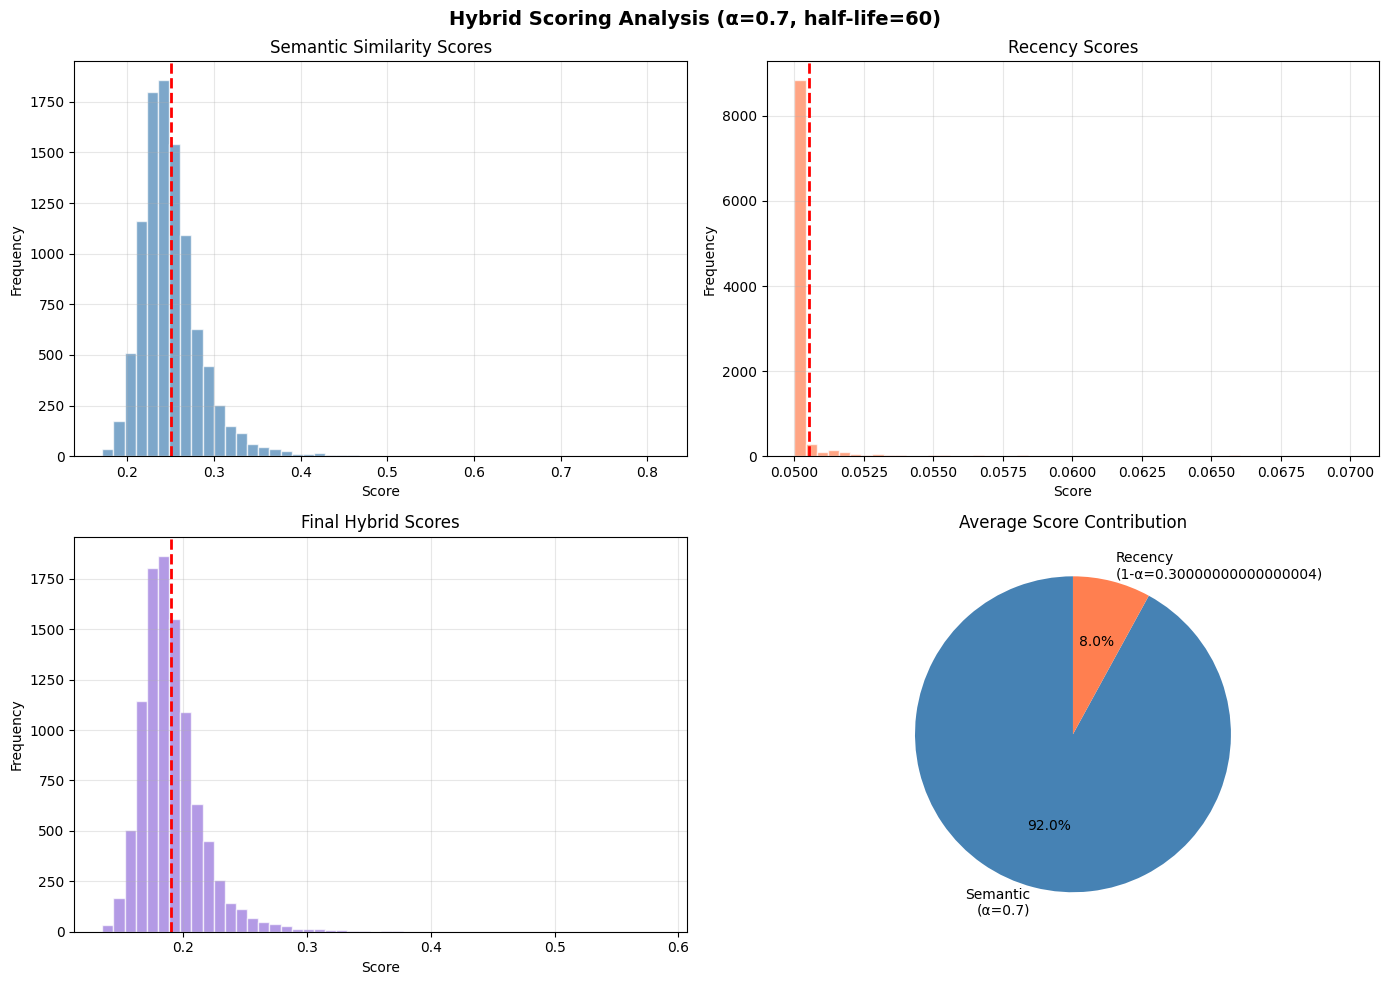


✓ Saved: recommendations/hybrid_scoring_analysis.png


In [24]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Hybrid Scoring Analysis (α={ALPHA}, half-life={HALF_LIFE})', fontsize=14, fontweight='bold')

# Plot 1: Semantic similarity
axes[0,0].hist(all_sim_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0,0].set_title('Semantic Similarity Scores')
axes[0,0].set_xlabel('Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(np.mean(all_sim_scores), color='red', linestyle='--', linewidth=2)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Recency
axes[0,1].hist(all_recency_scores, bins=50, color='coral', edgecolor='white', alpha=0.7)
axes[0,1].set_title('Recency Scores')
axes[0,1].set_xlabel('Score')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(np.mean(all_recency_scores), color='red', linestyle='--', linewidth=2)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Final scores
axes[1,0].hist(all_final_scores, bins=50, color='mediumpurple', edgecolor='white', alpha=0.7)
axes[1,0].set_title('Final Hybrid Scores')
axes[1,0].set_xlabel('Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(np.mean(all_final_scores), color='red', linestyle='--', linewidth=2)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Contribution pie chart
components = [alpha_contribution, recency_contribution]
labels = [f'Semantic\n(α={ALPHA})', f'Recency\n(1-α={1-ALPHA})']
colors = ['steelblue', 'coral']
axes[1,1].pie(components, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Average Score Contribution')

plt.tight_layout()
plt.savefig('recommendations/hybrid_scoring_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: recommendations/hybrid_scoring_analysis.png")